In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
from scipy.stats import norm

In [2]:
df = pd.read_csv("Telco_Cusomer_Churn.csv")

In [3]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df.dropna(inplace=True)

In [4]:
df.drop('customerID', axis=1, inplace=True)

# Chi-Square Test

Hypotheses

H₀:

Contract and Churn are independent.

H₁:

Contract and Churn are associated.

In [5]:
contract_table = pd.crosstab(
    df['Contract'],
    df['Churn']
)

contract_table

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [6]:
chi2, p, dof, expected = chi2_contingency(
    contract_table
)

print("Chi-square:", chi2)
print("P-value:", p)

Chi-square: 1179.5458287339445
P-value: 7.326182186265472e-257


### Contract Type vs Churn

A Chi-Square test of independence was conducted to examine the relationship between contract type and customer churn.

The test produced a Chi-Square statistic of 1179.55 with a p-value of 7.33 × 10⁻²⁵⁷.

Since the p-value is far below 0.05, the null hypothesis was rejected.

This indicates a statistically significant association between contract type and churn.

Customers on month-to-month contracts are substantially more likely to churn compared to customers on one-year or two-year contracts. Long-term contracts appear to be an important factor in customer retention.

In [7]:
internet_table = pd.crosstab(
    df['InternetService'],
    df['Churn']
)

internet_table

Churn,No,Yes
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


In [8]:
chi2, p, dof, expected = chi2_contingency(
    internet_table
)

print("Chi-square:", chi2)
print("P-value:", p)

Chi-square: 728.6956143058694
P-value: 5.831198962237274e-159


In [9]:
payment_table = pd.crosstab(
    df['PaymentMethod'],
    df['Churn']
)

payment_table

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


In [10]:
chi2, p, dof, expected = chi2_contingency(
    payment_table
)

print("Chi-square:", chi2)
print("P-value:", p)

Chi-square: 645.4299001234638
P-value: 1.4263098511063342e-139


### Payment Method vs Churn

A Chi-Square test of independence was conducted to examine the relationship between payment method and customer churn.

The test produced a Chi-Square statistic of 645.43 and a p-value of 1.43 × 10⁻¹³⁹.

Since the p-value is significantly below 0.05, the null hypothesis was rejected.

This indicates a statistically significant association between payment method and churn.

Customers using Electronic Check exhibit substantially higher churn rates than customers using other payment methods. Payment behavior appears to be an important indicator of customer retention.

In [11]:
num_cols = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

corr = df[num_cols].corr()

corr

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.246862,0.825880
MonthlyCharges,0.246862,1.000000,0.651065
TotalCharges,0.825880,0.651065,1.000000


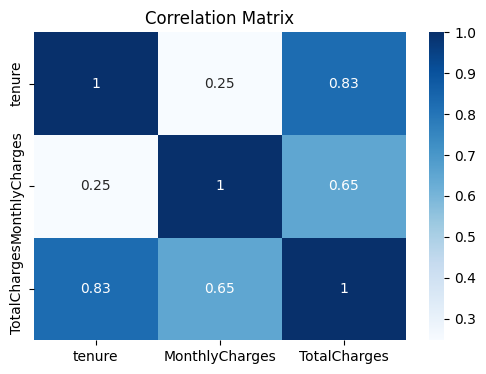

In [12]:
plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Matrix")

plt.show()

### Correlation Analysis

The strongest correlation was observed between Tenure and TotalCharges (r = 0.83), indicating a strong positive relationship.

This result is expected because customers who remain with the company for longer periods accumulate larger total charges over time.

MonthlyCharges and TotalCharges showed a moderate positive correlation (r = 0.65), suggesting that customers with higher monthly bills generally contribute more total revenue.

Tenure and MonthlyCharges exhibited a weak positive relationship (r = 0.25), indicating that long-term customers do not necessarily subscribe to more expensive plans.

It is important to note that correlation measures association and does not imply causation.

What is Causation?

Causation means:

One variable directly causes a change in another variable.

What is the difference between correlation and causation?

Correlation measures the strength and direction of association between variables, while causation means one variable directly influences another. Correlation alone cannot establish causality because confounding variables or reverse causality may exist.

In [13]:
churned = df[
    df['Churn'] == 'Yes'
]['MonthlyCharges']

In [14]:
mean = churned.mean()

std = churned.std()

n = len(churned)

print("Mean =", mean)
print("Std =", std)
print("n =", n)

Mean = 74.44133226324237
Std = 24.666053259397433
n = 1869


In [15]:
se = std / np.sqrt(n)

print(se)

0.5705517137854327


In [16]:
margin = 1.96 * se

print(margin)

1.118281359019448


In [17]:
lower = mean - margin
upper = mean + margin

print("Lower =", lower)
print("Upper =", upper)

Lower = 73.32305090422292
Upper = 75.55961362226182


### Confidence Interval for Monthly Charges of Churned Customers

A 95% confidence interval was constructed for the mean monthly charge of churned customers.

The interval was calculated as:

(73.32, 75.56)

We are 95% confident that the true average monthly charge of churned customers lies between 73.32 and 75.56.

The interval is relatively narrow due to the large sample size (n = 1869), indicating that the estimate is precise and reliable.

In [18]:
churn_yes = df[
    df['Churn'] == 'Yes'
]['MonthlyCharges']

churn_no = df[
    df['Churn'] == 'No'
]['MonthlyCharges']

In [19]:
print(churn_yes.mean())
print(churn_no.mean())

74.44133226324237
61.307408483439865


In [20]:
from scipy.stats import ttest_ind

t_stat, p = ttest_ind(
    churn_yes,
    churn_no
)

print("T-statistic =", t_stat)
print("P-value =", p)

T-statistic = 16.47959313114872
P-value = 6.760843117980123e-60


In [21]:
if p < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Reject H0


### Independent Sample T-Test

An independent sample t-test was conducted to compare monthly charges between churned and non-churned customers.

The average monthly charge for churned customers was 74.44, while the average monthly charge for non-churned customers was 61.31.

The test produced a t-statistic of 16.48 and a p-value of 6.76 × 10⁻⁶⁰.

Since the p-value is significantly below 0.05, the null hypothesis was rejected.

This indicates that monthly charges differ significantly between churned and non-churned customers.

Customers with higher monthly charges appear more likely to churn.